<a href="https://colab.research.google.com/github/khushirajput01/Motorola-Sales-Performance-Dashboard/blob/main/Final_retail_price_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import joblib
import ssl

import warnings
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"
warnings.filterwarnings('ignore')

# Loading Data

In [ ]:
ssl._create_default_https_context = ssl._create_stdlib_context
url="https://raw.githubusercontent.com/Gyandubey6672/Data-Structures-C/refs/heads/main/retail_price.csv"
data = pd.read_csv(url, encoding= 'unicode_escape')
df=data

#Data Analysis

In [ ]:
df.shape


(676, 30)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

In [ ]:
df.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='object')

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
qty,676.0,14.495562,15.443421,1.000000,4.000000,10.000000,18.000000,122.00
total_price,676.0,1422.708728,1700.123100,19.900000,333.700000,807.890000,1887.322500,12095.00
freight_price,676.0,20.682270,10.081817,0.000000,14.761912,17.518472,22.713558,79.76
unit_price,676.0,106.496800,76.182972,19.900000,53.900000,89.900000,129.990000,364.00
product_name_lenght,676.0,48.720414,9.420715,29.000000,40.000000,51.000000,57.000000,60.00
product_description_lenght,676.0,767.399408,655.205015,100.000000,339.000000,501.000000,903.000000,3006.00
product_photos_qty,676.0,1.994083,1.420473,1.000000,1.000000,1.500000,2.000000,8.00
product_weight_g,676.0,1847.498521,2274.808483,100.000000,348.000000,950.000000,1850.000000,9750.00
product_score,676.0,4.085503,0.232021,3.300000,3.900000,4.100000,4.200000,4.50
customers,676.0,81.028107,62.055560,1.000000,34.000000,62.000000,116.000000,339.00


In [ ]:
df.dtypes

,0
product_id,object
product_category_name,object
month_year,object
qty,int64
total_price,float64
freight_price,float64
unit_price,float64
product_name_lenght,int64
product_description_lenght,int64
product_photos_qty,int64


In [ ]:
df.head(2)

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,1/5/2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.0,4.4,8.760,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,1/6/2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.0,4.4,21.322,45.95,4.0,12.933333,45.95


In [ ]:
df.nunique()

,0
product_id,52
product_category_name,9
month_year,20
qty,66
total_price,573
freight_price,653
unit_price,280
product_name_lenght,24
product_description_lenght,46
product_photos_qty,7


In [ ]:
df['qty'].sum()

np.int64(9799)

In [ ]:
df['total_price'].sum()

np.float64(961751.0999999999)

In [ ]:
df.count()

,0
product_id,676
product_category_name,676
month_year,676
qty,676
total_price,676
freight_price,676
unit_price,676
product_name_lenght,676
product_description_lenght,676
product_photos_qty,676


#Monthly Sales Analysis

In [ ]:
monthly_df = data.groupby('month_year').agg({
    'qty': 'sum',
    'weekday': 'sum',
    'weekend': 'sum',
    'customers': 'sum'
}).reset_index()
monthly_df['month_year'] = pd.to_datetime(monthly_df['month_year'], format='%m/%d/%Y')
monthly_df = monthly_df.sort_values(by='month_year')
print(monthly_df)

   month_year   qty  weekday  weekend  customers
0  2017-01-01     9       44       18         18
5  2017-01-02    35      180       72         78
7  2017-01-03   101      299      104        242
9  2017-01-04   121      300      150        309
11 2017-01-05   222      460      160        803
13 2017-01-06   233      550      200        820
15 2017-01-07   403      693      330       1686
17 2017-01-08   495      851      296       2279
19 2017-01-09   450      756      324       2275
2  2017-01-10   550      946      387       2949
3  2017-01-11  1051      968      352       6108
4  2017-01-12   678      924      440       3874
1  2018-01-01   866     1104      384       4874
6  2018-01-02   869      980      392       5238
8  2018-01-03   824     1100      450       5276
10 2018-01-04   760     1008      432       4653
12 2018-01-05   898      920      320       5294
14 2018-01-06   474      882      378       3075
16 2018-01-07   427      880      360       2769
18 2018-01-08   333 

In [ ]:
monthly_df.head()

,month_year,qty,weekday,weekend,customers
0,2017-01-01,9,44,18,18
5,2017-01-02,35,180,72,78
7,2017-01-03,101,299,104,242
9,2017-01-04,121,300,150,309
11,2017-01-05,222,460,160,803


In [ ]:
monthly_df = data.groupby('month_year').agg({
    'qty': 'sum',
    'weekday': 'sum',
    'weekend': 'sum',
    'customers': 'sum',
    'total_price': 'sum'
}).reset_index()

monthly_df['month_year'] = pd.to_datetime(monthly_df['month_year'], infer_datetime_format=True)

monthly_df = monthly_df.sort_values(by='month_year')


#Feature Engineering

In [ ]:
products_sum = pd.DataFrame({
    'product_id': [1, 2, 3],
    'total_price': [100, 200, 300]
})

products_mean = pd.DataFrame({
    'product_id': [1, 2, 3],
    'unit_price': [10, 20, 30]
})

combined_df = pd.concat([products_sum, products_mean], axis=1, join='inner').reset_index()

print(combined_df.head())

   index  product_id  total_price  product_id  unit_price
0      0           1          100           1          10
1      1           2          200           2          20
2      2           3          300           3          30


In [ ]:
products = pd.concat([products_sum, products_mean],
                   axis=1, join='inner').reset_index()

products.head()

,index,product_id,total_price,product_id,unit_price
0,0,1,100,1,10
1,1,2,200,2,20
2,2,3,300,3,30


In [ ]:
products=data

In [ ]:
X, y = products.drop(['product_id', 'unit_price'], axis=1), products['unit_price']

print(X)
print(y)

    product_category_name month_year  qty  total_price  freight_price  \
0          bed_bath_table   1/5/2017    1        45.95      15.100000   
1          bed_bath_table   1/6/2017    3       137.85      12.933333   
2          bed_bath_table   1/7/2017    6       275.70      14.840000   
3          bed_bath_table   1/8/2017    4       183.80      14.287500   
4          bed_bath_table   1/9/2017    2        91.90      15.100000   
..                    ...        ...  ...          ...            ...   
671        bed_bath_table   1/5/2017    1       215.00       8.760000   
672        bed_bath_table   1/6/2017   10      2090.00      21.322000   
673        bed_bath_table   1/7/2017   59     12095.00      22.195932   
674        bed_bath_table   1/8/2017   52     10375.00      19.412885   
675        bed_bath_table   1/9/2017   32      5222.36      24.324687   

     product_name_lenght  product_description_lenght  product_photos_qty  \
0                     39                       

#Data cleaning


In [ ]:
print(data.isnull().sum())
data =data.dropna()

product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: int64


#Data Transformation


In [ ]:
non_numeric_columns = data.select_dtypes(include=['object']).columns
numeric_data = data.drop(columns=non_numeric_columns)

Scaler = StandardScaler()
scaled_data = Scaler.fit_transform(numeric_data)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_data.columns)

#Linear Regression model

In [ ]:
X = data.drop(columns='total_price')
y = data['total_price']

non_numeric_columns = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=non_numeric_columns, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.1, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}, R-squared: {r2}')

MSE: 1207565.4710657648, R-squared: 0.6258298281466881


#Prediction

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
new_input_data = {
    'feature1': [10],
    'feature2': [20],
    'feature3': [89.9],
    'feature4': [45.95],
    'feature5': [20],
}

new_input_df = pd.DataFrame(new_input_data)

new_input_encoded = pd.get_dummies(new_input_df)

new_input_aligned = new_input_encoded.reindex(columns=X_train.columns, fill_value=0)

scaled_input = scaler.transform(new_input_aligned)

predicted_price = model.predict(scaled_input)
print(f'Predicted Price: {predicted_price}')

Predicted Price: [683425.04001293]


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y,
    y=y_pred,
    mode='markers',
    marker=dict(color='blue'),  # Fixed here
    name='Predicted vs. Actual Retail Unit Price'
))

fig.add_trace(go.Scatter(
    x=[min(y), max(y)],
    y=[min(y), max(y)],
    mode='lines',
    line=dict(color='red'),
    name='Ideal Prediction'
))

fig.update_layout(
    title='Predicted vs. Actual Retail Price',
    xaxis_title='Actual Retail Price',
    yaxis_title='Predicted Retail Price'
)

fig.show()


#Graph

In [ ]:
fig = px.scatter(data, x='unit_price', y='qty', title='Unit Price vs Quantity Sold')
fig.show()
numeric_data = data.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_data.corr()

heatmap_fig = px.imshow(corr_matrix, title="Correlation Matrix")
heatmap_fig.show()

In [ ]:
fig = px.scatter(
    monthly_df,
    x='weekend',
    y='total_price',
    trendline='ols',
    title='Weekly Analysis of Total Price'
)

fig.show()

In [ ]:
df=data
fig=px.histogram(df,
x='total_price',
nbins=20,
title='Distribution of Total Price')
fig.show()

In [ ]:
fig = px.scatter(df,
x='qty',
y='total_price', trendline='ols',
title='Quantity vs Total Price')
fig.show()

In [ ]:
fig=px.bar(df,x='product_category_name',
y='total_price', title='Total Price by Product Category')
fig.show()

In [ ]:
df['comp1_diff'] = df['unit_price'] - df['comp_1']
df['comp2_diff'] = df['unit_price'] - df['comp_2']
df['comp3_diff'] = df['unit_price'] - df['comp_3']

for i in range(1, 4):
    comp = f"comp{i}_diff"

    fig = px.bar(
        x=df['product_category_name'],
        y=df[comp],
        title=f"Competitor {i} Price Difference per Unit",
        labels={
            'x': 'Product Category',
            'y': f'Competitor {i} Price Difference'
        }
    )

    fig.show()


In [ ]:
df['fp1_diff'] = df['freight_price'] - df['fp1']
df['fp2_diff'] = df['freight_price'] - df['fp2']
df['fp3_diff'] = df['freight_price'] - df['fp3']

for i in range(1, 4):
    comp = f"fp{i}_diff"
    fig = px.bar(
        x=df['product_category_name'],
        y=df[comp],
        title=f"Competitor {i} Shipping Price Difference",
        labels={
            'x': 'Product Category',
            'y': f'Competitor {i} Price Difference'
        }
    )

    fig.show()


In [ ]:
numeric_df = df.select_dtypes(include='number')
corrs = numeric_df.corr()['unit_price'].sort_values(ascending=False)
fig = px.bar(x=corrs.keys(), y=corrs.values,
             title='Correlation of Features with Unit Price',
             labels={
                 'x': 'Features',
                 'y': 'Correlation with Unit Price'
             })
fig.show()

In [ ]:
fig=px.bar (monthly_df,
                x='month_year', y='customers',
                title='Customers per month')
fig.show()


#Exploratory Data Analysis

Calculate Revenue and Profit:

In [ ]:
df['revenue']=df['qty']*df['total_price']
df['profit']=df['revenue']-df['freight_price']

Calculate Margin:

In [ ]:
df['margin']=df['profit']/df['revenue']*100

Price Ratios:

In [ ]:
df['price_ratio_1']=df['unit_price']/df['comp_1']
df['price_ratio-2']=df['unit_price']/df['comp_2']
df['price_ratio-3']=df['unit_price']/df['comp_3']

Price Differences:

In [ ]:
df['price_diff_1']=df['unit_price']-df['comp_1']
df['price_diff_2']=df['unit_price']-df['comp_2']
df['price_diff_3']=df['unit_price']-df['comp_3']

In [ ]:
df.head(3).transpose()

,0,1,2
product_id,bed1,bed1,bed1
product_category_name,bed_bath_table,bed_bath_table,bed_bath_table
month_year,1/5/2017,1/6/2017,1/7/2017
qty,1,3,6
total_price,45.95,137.85,275.7
freight_price,15.1,12.933333,14.84
unit_price,45.95,45.95,45.95
product_name_lenght,39,39,39
product_description_lenght,161,161,161
product_photos_qty,2,2,2


Market Demand Indicators:

In [ ]:
import numpy as np

# Check existing columns
print(df.columns)

# Assuming 'product_photos_qty' is the intended column for customer_photo_ratio
df['customers_score_ratio'] = df['customers'] / df['product_score']

# Replace zeros with NaN in product_photos_qty to avoid division by zero
df['product_photos_qty'].replace(0, np.nan, inplace=True)  # Optional: Avoid division by zero
df['customer_photo_ratio'] = df['customers'] / df['product_photos_qty']


Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price', 'comp1_diff', 'comp2_diff',
       'comp3_diff', 'fp1_diff', 'fp2_diff', 'fp3_diff', 'revenue', 'profit',
       'margin', 'price_ratio_1', 'price_ratio-2', 'price_ratio-3',
       'price_diff_1', 'price_diff_2', 'price_diff_3'],
      dtype='object')


In [ ]:
df.head(3).transpose()

,0,1,2
product_id,bed1,bed1,bed1
product_category_name,bed_bath_table,bed_bath_table,bed_bath_table
month_year,1/5/2017,1/6/2017,1/7/2017
qty,1,3,6
total_price,45.95,137.85,275.7
freight_price,15.1,12.933333,14.84
unit_price,45.95,45.95,45.95
product_name_lenght,39,39,39
product_description_lenght,161,161,161
product_photos_qty,2,2,2


Time-related Features:

In [ ]:
df['month_year']=pd.to_datetime(df['month_year'])
df['month']=df['month_year'].dt.month
df['year']=df['month_year'].dt.year
df['is_weekend']=df['weekday'].apply(lambda x: 1 if x>5 else 0)
df['is_holiday']=df['holiday']

In [ ]:
df.head(3).transpose()

,0,1,2
product_id,bed1,bed1,bed1
product_category_name,bed_bath_table,bed_bath_table,bed_bath_table
month_year,2017-01-05 00:00:00,2017-01-06 00:00:00,2017-01-07 00:00:00
qty,1,3,6
total_price,45.95,137.85,275.7
freight_price,15.1,12.933333,14.84
unit_price,45.95,45.95,45.95
product_name_lenght,39,39,39
product_description_lenght,161,161,161
product_photos_qty,2,2,2


Lagged Price:

In [ ]:
df['lag_price']=df.groupby('product_id')['unit_price'].shift(1)

Handling Categorical Variables:

In [ ]:
# One-hot encoding example
df_encoded=pd.get_dummies(df, columns=['product_category_name','weekday'])

Scaling Numbric Features:

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numeric_features=['qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
                  'product_description_lenght', 'product_photos_qty', 'product_weight_g',
                  'product_score', 'customers', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2',
                  'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']
df_scaled=df_encoded.copy()
df_scaled [numeric_features]=scaler.fit_transform(df_encoded [numeric_features])


Data Visualization

In [ ]:
df.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price', 'comp1_diff', 'comp2_diff',
       'comp3_diff', 'fp1_diff', 'fp2_diff', 'fp3_diff', 'revenue', 'profit',
       'margin', 'price_ratio_1', 'price_ratio-2', 'price_ratio-3',
       'price_diff_1', 'price_diff_2', 'price_diff_3', 'customers_score_ratio',
       'customer_photo_ratio', 'is_weekend', 'is_holiday'],
      dtype='object')

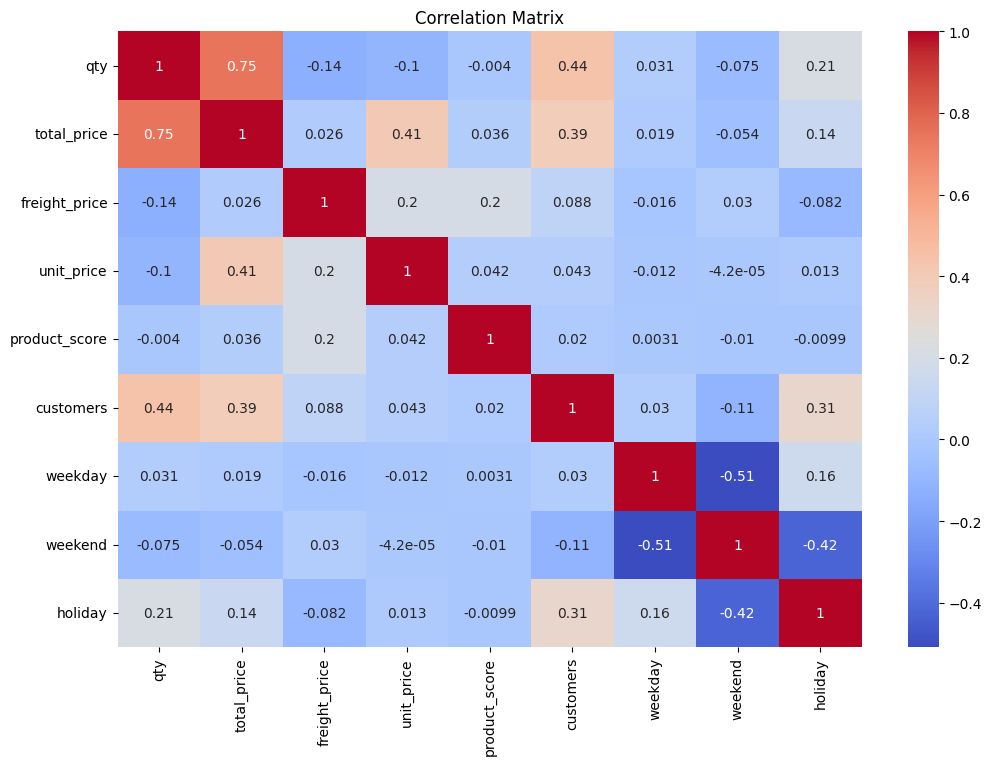

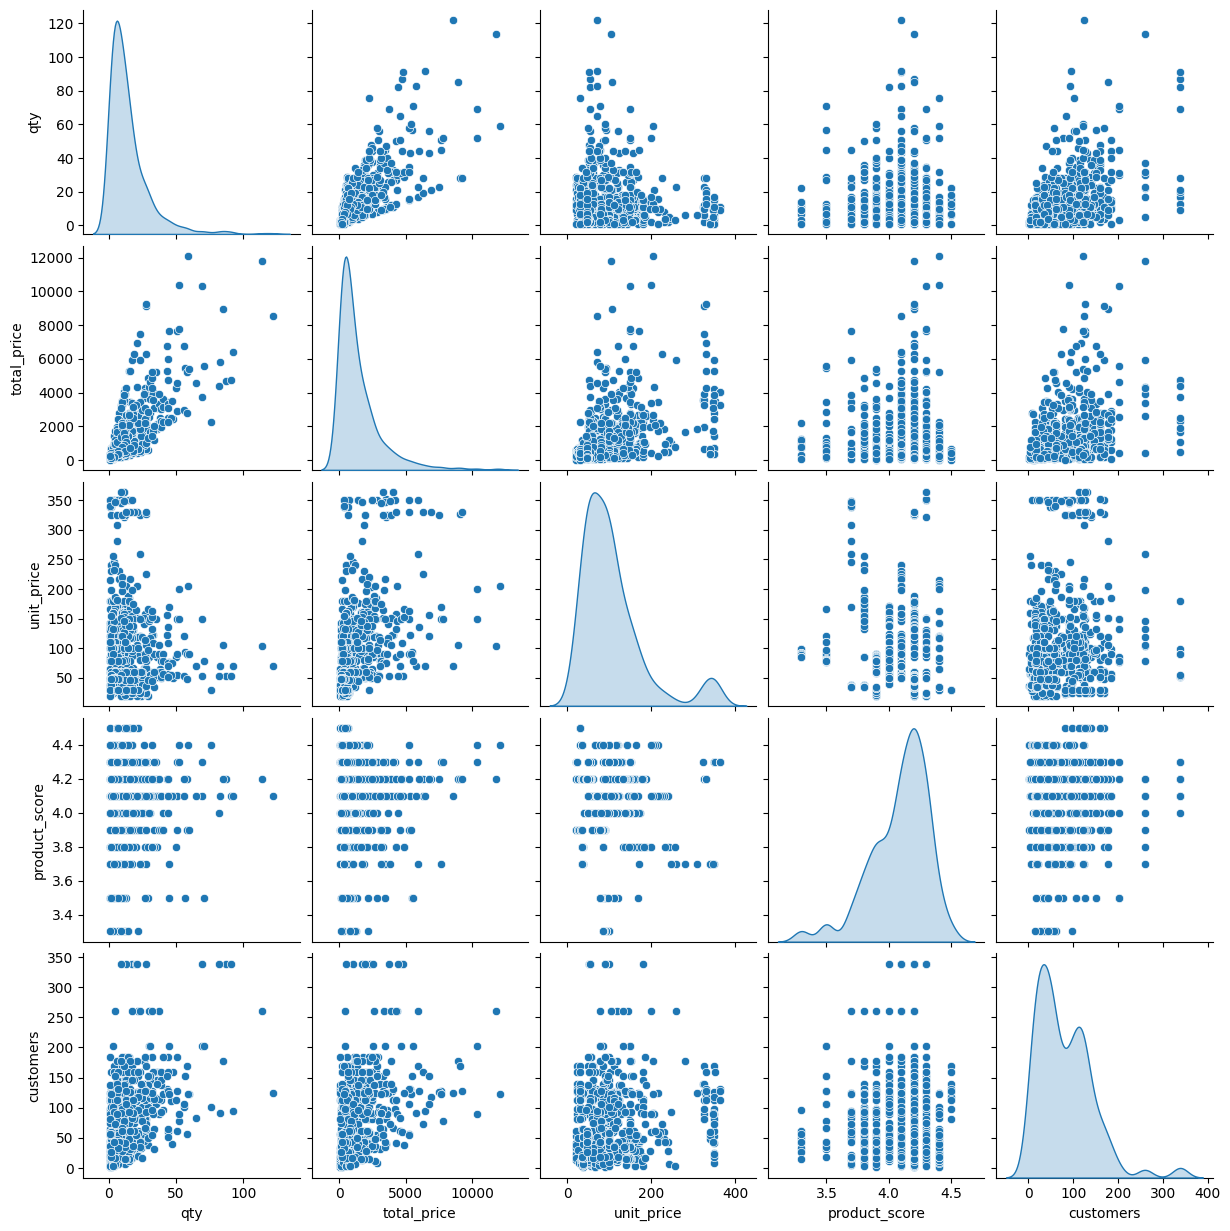

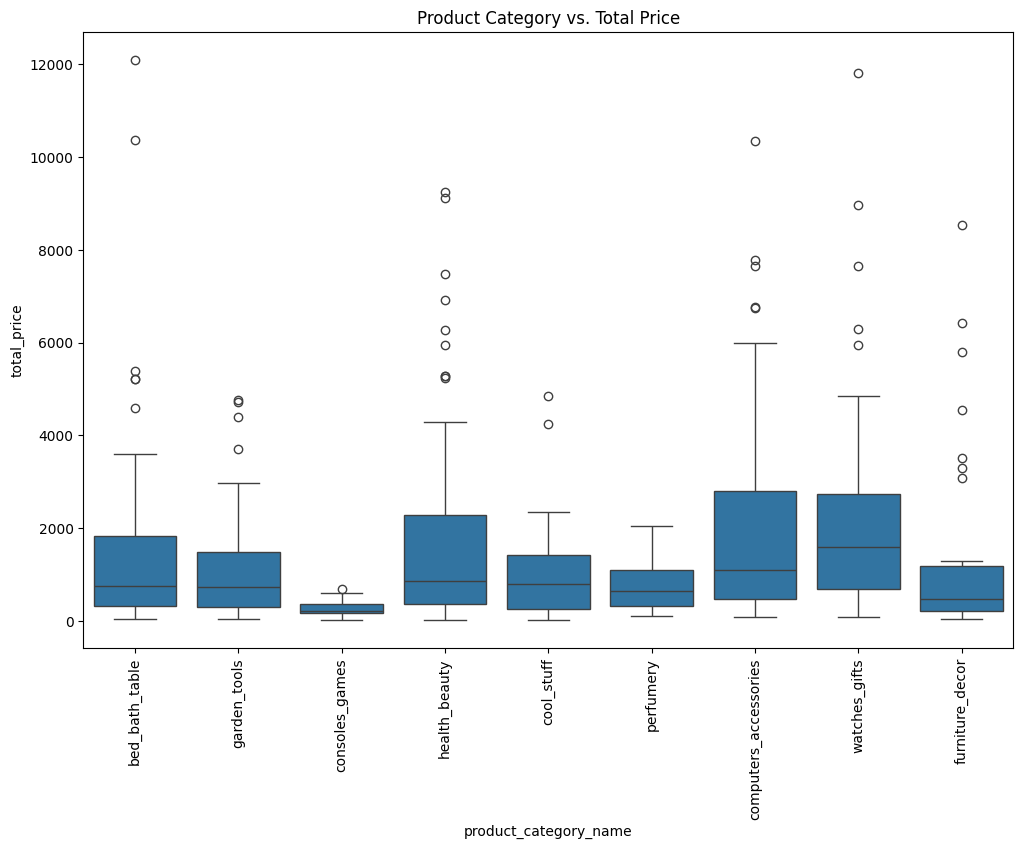

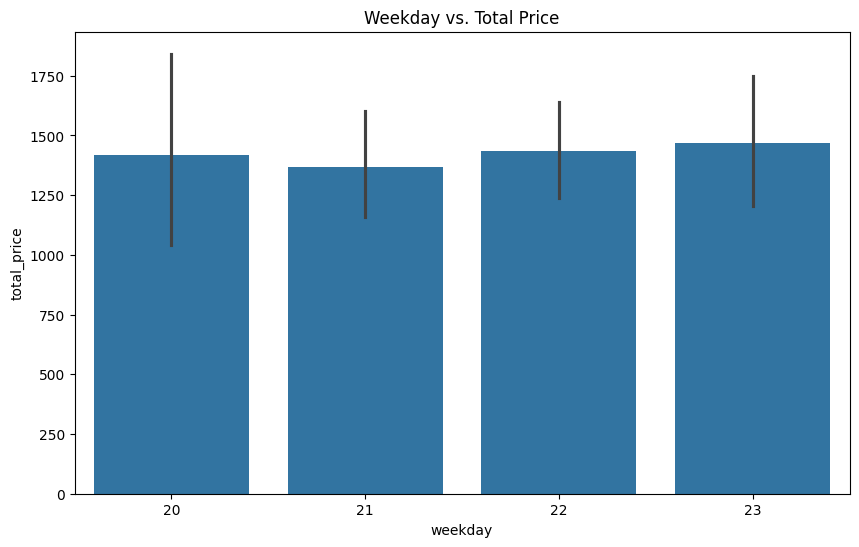

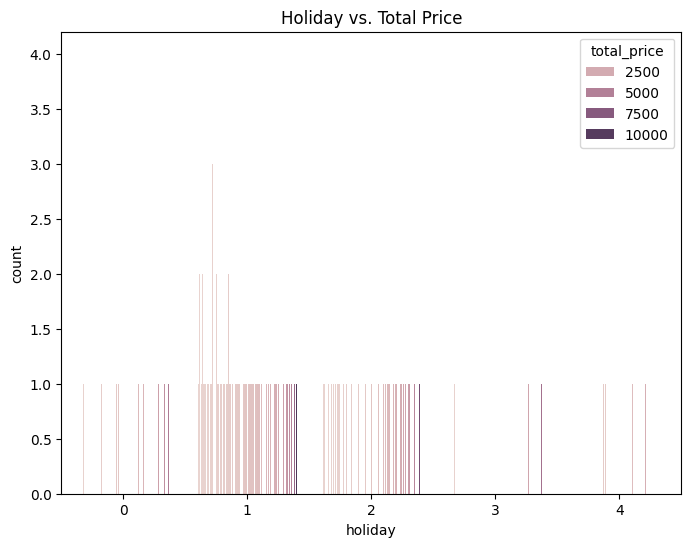

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Subset the dataset with relevant columns
subset_cols = ['qty', 'total_price', 'freight_price', 'unit_price', 'product_score', 'customers', 'weekday', 'weekend', 'holiday']
subset_df = df[subset_cols]

# Compute the correlation matrix
corr_matrix = subset_df.corr()  # Corrected from corri() to corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Pairwise scatter plot
sns.pairplot(subset_df, vars=['qty', 'total_price', 'unit_price', 'product_score', 'customers'], diag_kind='kde')
plt.show()

# Boxplot of product_category_name vs. total price
plt.figure(figsize=(12, 8))
sns.boxplot(x='product_category_name', y='total_price', data=df)
plt.title('Product Category vs. Total Price')
plt.xticks(rotation=90)
plt.show()

# Bar plot of weekday vs. total_price
plt.figure(figsize=(10, 6))
sns.barplot(x='weekday', y='total_price', data=df)
plt.title('Weekday vs. Total Price')
plt.show()

# Count plot of holiday vs. total_price
plt.figure(figsize=(8, 6))
sns.countplot(x='holiday', data=df, hue='total_price')
plt.title('Holiday vs. Total Price')
plt.show()
